# 05 — 2026-10-04: abstention, question-only floor, mismatched video, explanations

Follow-up to the pilot (notebook 04). Same model, frames and question order. For each of the first `N_QUESTIONS`
questions (fixed order from notebook 03), five conditions:

| condition | input | options |
|---|---|---|
| `Q_noE` | question | A–D (floor, comparable to the pilot) |
| `Q` | question | A–E |
| `T` | transcript + question | A–E |
| `VT` | T + 64 silent frames of the question's own clip | A–E |
| `VTmis` | T + 64 silent frames of a clip from a **different film** | A–E |

Option E is *"Cannot tell from the given information."* Scoring is unchanged from the pilot: the probability of each
letter as the next token. After scoring, the model's own top letter is put in the chat as its answer and it is asked
*"Why did you choose this answer? Explain in one sentence."* (greedy decoding). The explanation cannot change the scores.

Settings and prompt texts are in `configs/2026-10-04_abstain_mismatch_explain.toml`. Results are appended to
`outputs/2026-10-04_abstain_mismatch_explain/results.jsonl` as soon as each one is computed; finished
(question, condition) pairs are skipped, so you can stop any time or raise `N_QUESTIONS` and rerun.
The run uses no answer keys; they are loaded only in the analysis section.

In [16]:
N_QUESTIONS = None  # None = all 598 questions
CONDITIONS = None  # None = all conditions from the config, or a subset, e.g. ["Q_noE", "Q", "T"]

In [17]:
import sys, json, time, tomllib
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import qwen_omni as qo

CFG_PATH = ROOT / "configs/2026-10-04_abstain_mismatch_explain.toml"
CFG = tomllib.loads(CFG_PATH.read_text())
CONDITIONS = CONDITIONS or CFG["conditions"]
assert set(CONDITIONS) <= set(CFG["conditions"]), CONDITIONS
EXP_DIR = ROOT / "outputs" / CFG["experiment"]
EXP_DIR.mkdir(parents=True, exist_ok=True)
OUT = EXP_DIR / "results.jsonl"

all_questions = pd.read_parquet(ROOT / "data/processed/emotion_questions.parquet")
questions = all_questions.head(N_QUESTIONS)
print(f"{len(questions)} questions, conditions {CONDITIONS} -> {OUT.relative_to(ROOT)}")

598 questions, conditions ['Q_noE', 'Q', 'T', 'VT', 'VTmis'] -> outputs/2026-10-04_abstain_mismatch_explain/results.jsonl


## Mismatched clips

Each question gets the clip of another Emotions question from a **different film**: the one whose clip length is
closest to its own (ties: the earlier one in the fixed order). The pairing is computed over all 598 questions, so it does
not depend on `N_QUESTIONS`. The mismatched clip uses its own frame count (64 for all but the 6 short clips). Only the
video changes: transcript, question and options are the question's own.

In [18]:
mismatch = {}  # question_id -> the question whose clip is shown in VTmis
for q in all_questions.itertuples():
    other = all_questions[all_questions.movie_title != q.movie_title]
    gap = (other.focused_duration_s - q.focused_duration_s).abs()
    mismatch[q.question_id] = other.loc[gap.idxmin()]

pairs = pd.DataFrame({"question_id": list(mismatch),
                      "clip_s": all_questions.focused_duration_s.values,
                      "mis_question_id": [m.question_id for m in mismatch.values()],
                      "mis_movie_title": [m.movie_title for m in mismatch.values()],
                      "mis_clip_s": [m.focused_duration_s for m in mismatch.values()]})
pairs.to_csv(EXP_DIR / "mismatch_pairs.csv", index=False)
print("median |clip length difference| (s):", round((pairs.clip_s - pairs.mis_clip_s).abs().median(), 2))
pairs.head().round(1)

median |clip length difference| (s): 0.05


,question_id,clip_s,mis_question_id,mis_movie_title,mis_clip_s
0,FH-76,21.3,x40a1,MAN TO MAN,21.2
1,97rJU,47.5,ZNAaV,DUSSELDORF,47.6
2,cP4lM,294.0,hjEci,POMMEL,291.1
3,XESWo,55.0,iBIiz,COOL FOR FIVE SECONDS,55.1
4,6p7dK,21.4,kREcQ,THE REFEREE,21.4


## Load the model (~18 GB RAM, a few minutes)

In [19]:
processor, model = qo.load(CFG["model_revision"])

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1346 [00:00<?, ?it/s]

[transformers] Qwen2_5OmniThinkerForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-7B
Key                                                                                                      | Status     |  | 
---------------------------------------------------------------------------------------------------------+------------+--+-
token2wav.code2wav_dit_model.transformer_blocks.{0...21}.attn.to_out.0.bias                              | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.activations.{0, 1, 2, 3, 4, 5}.act.alpha             | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.ups.{0, 1, 2, 3, 4, 5}.0.weight                                         | UNEXPECTED |  | 
talker.model.layers.{0...23}.mlp.down_proj.weight                                                        | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.resblocks.{0...17}.convs1.{0, 1, 2}.bias                                | UNEXPECTED |  | 
token2wav.code2wav_bigvgan_model.re

## Show the exact prompts for the first question

VT and VTmis have the same text as T, plus the video. The last block is the explanation turn, shown with "A" as a
placeholder; in the run it is the model's own top letter.

In [20]:
first = questions.iloc[0]
for title, text in [("Q_noE", qo.build_prompt(first, with_transcript=False)),
                    ("Q", qo.build_prompt(first, with_transcript=False, option_e=CFG["option_e"])),
                    ("T, VT, VTmis", qo.build_prompt(first, option_e=CFG["option_e"]))]:
    print(f"===== {title}")
    print(qo.make_inputs(processor, qo.SYSTEM_PROMPT, text)[1])
print("===== explanation turn (T)")
print(qo.make_inputs(processor, qo.SYSTEM_PROMPT, text, followup=("A", CFG["explain_prompt"]))[1])

===== Q_noE
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Question: How does the man feel about knocking on the door?
A. The man expresses sadness that he won't come inside.
B. The man expresses fear that there might not be anyone inside.
C. The man expresses annoyance.
D. The man expresses nervousness.

Answer with the option's letter only.<|im_end|>
<|im_start|>assistant

===== Q
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Question: How does the man feel about knocking on the door?
A. The man expresses sadness that he won't come inside.
B. The man expresses fear that there might not be anyone inside.
C. The man expresses annoyance.
D. The man expresses nervousness.
E. Cannot tell from the given information.

Answer with the option's letter only.<|im_end|>
<|im_start|>assistant

===== T, VT, VTmis
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Transcript of the dialogue in the clip:
(no dialogue)



## Run

For each question and condition: score the letters, take the top one as the answer, ask for the explanation, append one row.

In [21]:
done = {(r["question_id"], r["condition"]) for r in map(json.loads, OUT.open())} if OUT.exists() else set()
print(f"{len(done)} results already in {OUT.name}")

for q in tqdm(questions.itertuples(), total=len(questions), unit="question"):
    for condition in CONDITIONS:
        if (q.question_id, condition) in done:
            continue
        t0 = time.time()

        # text: Q_noE has no option E; Q_noE and Q have no transcript
        option_e = None if condition == "Q_noE" else CFG["option_e"]
        letters = qo.LETTERS if condition == "Q_noE" else qo.LETTERS + ["E"]
        user_text = qo.build_prompt(q._asdict(), with_transcript=condition in ["T", "VT", "VTmis"], option_e=option_e)

        # video: the question's own clip (VT) or the mismatched clip (VTmis)
        clip, frames, fps = None, None, None
        if condition == "VT":
            clip = q
        if condition == "VTmis":
            clip = mismatch[q.question_id]
        if clip is not None:
            video = ROOT / "data/raw/all_videos" / f"{clip.movie_title}.mp4"
            frames, fps = qo.sample_frames(video, clip.t_i, clip.t_j, int(clip.n_frames), CFG["max_pixels"])

        # 1) score the letters
        inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text, frames, fps)
        r = qo.score_options(model, processor, inputs, letters)
        answer = letters[r["prob"].index(max(r["prob"]))]
        t1 = time.time()

        # 2) explanation: the model's answer goes into the chat, then the follow-up question
        inputs, _ = qo.make_inputs(processor, qo.SYSTEM_PROMPT, user_text, frames, fps,
                                   followup=(answer, CFG["explain_prompt"]))
        e = qo.generate_text(model, processor, inputs, CFG["explain_max_new_tokens"])

        row = {"order": q.order, "question_id": q.question_id, "condition": condition,
               **{f"prob_{L}": p for L, p in zip(letters, r["prob"])},
               "mass_on_letters": r["mass_on_letters"], "n_input_tokens": r["n_input_tokens"], "answer": answer,
               "explanation": e["text"], "explanation_tokens": e["n_tokens"], "explanation_hit_limit": e["hit_limit"],
               "score_seconds": round(t1 - t0, 1), "explain_seconds": round(time.time() - t1, 1),
               "video_question_id": None if clip is None else clip.question_id,
               "n_frames": 0 if frames is None else len(frames),
               "max_pixels": CFG["max_pixels"], "model_revision": CFG["model_revision"]}
        with OUT.open("a") as f:
            f.write(json.dumps(row) + "\n")

50 results already in results.jsonl


  0%|          | 0/598 [00:00<?, ?question/s]

[h264 @ 0x461f5f00] mmco: unref short failure
[h264 @ 0x461f5f00] mmco: unref short failure
[h264 @ 0x461f5f00] mmco: unref short failure
[h264 @ 0x461f5f00] mmco: unref short failure
[h264 @ 0x461f5f00] mmco: unref short failure
[h264 @ 0x447c2080] mmco: unref short failure
[h264 @ 0x448a3a00] mmco: unref short failure
[h264 @ 0x448a3a00] mmco: unref short failure
[h264 @ 0x695de040] mmco: unref short failure
[h264 @ 0x628efe00] mmco: unref short failure


KeyboardInterrupt: 

## Results so far

This section reads only the results file and the answer keys. To rerun it without the model, run the first two code
cells, then jump here.

- **answer** = letter with the highest probability (E = abstain)
- **accuracy** = share answered with the correct letter (an abstention counts as not correct)
- **abstain** = share where E is the top letter; **p_E** = probability on E (a softer abstention score)
- **confidence** = top probability among A–D, renormalized over A–D (comparable with the pilot)
- **selective_accuracy** = accuracy on the questions that were not abstained on
- **confidently_wrong** = wrong A–D answer with confidence ≥ `HIGH_CONFIDENCE` (the critical failure), share of all questions

In [30]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

HIGH_CONFIDENCE = 0.8
FIGURES = EXP_DIR / "figures"
FIGURES.mkdir(exist_ok=True)

keys = pd.read_parquet(ROOT / "data/processed/answer_keys.parquet")[["question_id", "correct_answer_key"]]
info = all_questions[["question_id", "movie_title", "question", "cue_visual_any"]]
df = pd.read_json(OUT, lines=True).drop_duplicates(["question_id", "condition"]).merge(keys, on="question_id").merge(info, on="question_id")

# keep only questions that have every condition run so far, so all conditions are compared on the same questions
n_conditions = df.groupby("question_id").condition.transform("nunique")
df = df[n_conditions == df.condition.nunique()].copy()
conditions = [c for c in CFG["conditions"] if c in set(df.condition)]
print(df.question_id.nunique(), "questions with all of", conditions)

abcd = ["prob_A", "prob_B", "prob_C", "prob_D"]
df["abstain"] = df.answer == "E"
df["p_E"] = df.prob_E.fillna(0)  # Q_noE has no option E
df["correct"] = df.answer == df.correct_answer_key
df["confidence"] = df[abcd].max(axis=1) / df[abcd].sum(axis=1)
df["confidently_wrong"] = ~df.correct & ~df.abstain & (df.confidence >= HIGH_CONFIDENCE)

87 questions with all of ['Q_noE', 'Q', 'T', 'VT', 'VTmis']


In [31]:
summary = df.groupby("condition").agg(
    n=("correct", "size"),
    accuracy=("correct", "mean"),
    abstain=("abstain", "mean"),
    mean_p_E=("p_E", "mean"),
    confidence=("confidence", "mean"),
    confidently_wrong=("confidently_wrong", "mean"),
    mass_on_letters=("mass_on_letters", "mean"),
    score_seconds=("score_seconds", "mean"),
    explain_seconds=("explain_seconds", "mean"),
).reindex(conditions)
summary.insert(3, "selective_accuracy", df[~df.abstain].groupby("condition").correct.mean())
summary.round(3)

,n,accuracy,abstain,selective_accuracy,mean_p_E,confidence,confidently_wrong,mass_on_letters,score_seconds,explain_seconds
condition,,,,,,,,,,
Q_noE,87,0.540,0.000,0.540,0.000,0.701,0.092,1.0,1.310,18.760
Q,87,0.241,0.655,0.700,0.556,0.711,0.034,1.0,1.364,17.841
T,87,0.379,0.448,0.688,0.437,0.791,0.126,1.0,2.022,19.064
VT,87,0.483,0.310,0.700,0.348,0.816,0.092,1.0,80.914,98.971
VTmis,87,0.356,0.448,0.646,0.415,0.772,0.092,1.0,80.444,97.597


Split by whether the annotators tagged a visual cue (face / body). The hypothesis predicts, on visual-cue questions,
more abstention without video (Q, T) than with it (VT), and more abstention with the wrong video (VTmis) than the right one.

In [32]:
df.pivot_table(index="condition", columns="cue_visual_any", values=["correct", "abstain", "p_E", "confidently_wrong"],
               aggfunc="mean").reindex(conditions).round(3)

abstain        confidently_wrong        correct           p_E  \
cue_visual_any   False  True              False  True    False  True   False   
condition                                                                      
Q_noE            0.000  0.000             0.059  0.100   0.294  0.600  0.000   
Q                0.588  0.671             0.000  0.043   0.118  0.271  0.541   
T                0.471  0.443             0.176  0.114   0.235  0.414  0.362   
VT               0.294  0.314             0.235  0.057   0.294  0.529  0.353   
VTmis            0.353  0.471             0.235  0.057   0.235  0.386  0.338   

                       
cue_visual_any  True   
condition              
Q_noE           0.000  
Q               0.560  
T               0.455  
VT              0.347  
VTmis           0.433

### Paired comparisons (same questions)

Wilcoxon signed-rank test on the per-question difference in p_E and in A–D confidence. Only meaningful with enough questions.

In [33]:
wide = df.pivot(index="question_id", columns="condition", values=["p_E", "confidence"])
rows = []
for a, b in [("Q", "T"), ("T", "VT"), ("VT", "VTmis"), ("T", "VTmis")]:
    if a not in conditions or b not in conditions:
        continue
    for measure in ["p_E", "confidence"]:
        diff = wide[measure][b] - wide[measure][a]
        rows.append({"comparison": f"{b} - {a}", "measure": measure, "n": len(diff),
                     "mean_diff": diff.mean(), "median_diff": diff.median(),
                     "p": wilcoxon(diff).pvalue if (diff != 0).any() else None})
pd.DataFrame(rows).round(4)

,comparison,measure,n,mean_diff,median_diff,p
0,T - Q,p_E,87,-0.1189,-0.0685,0.0003
1,T - Q,confidence,87,0.0805,0.0686,0.0002
2,VT - T,p_E,87,-0.0892,-0.0449,0.0006
3,VT - T,confidence,87,0.0244,0.0133,0.2919
4,VTmis - VT,p_E,87,0.0668,0.0151,0.0046
5,VTmis - VT,confidence,87,-0.0438,-0.0120,0.0230
6,VTmis - T,p_E,87,-0.0225,-0.0236,0.0790
7,VTmis - T,confidence,87,-0.0194,0.0105,0.9831


### Plot

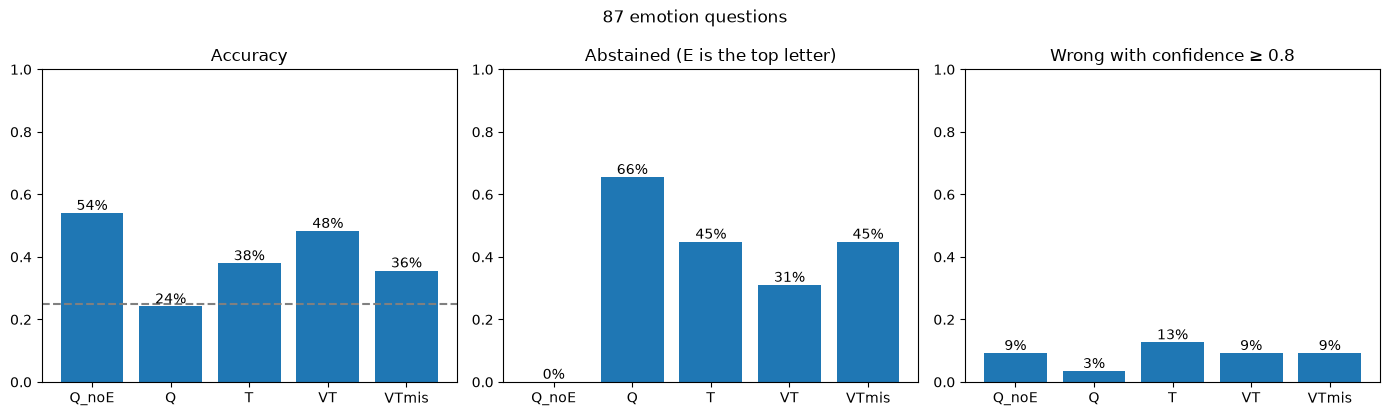

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, title in [(axes[0], "accuracy", "Accuracy"),
                       (axes[1], "abstain", "Abstained (E is the top letter)"),
                       (axes[2], "confidently_wrong", f"Wrong with confidence ≥ {HIGH_CONFIDENCE}")]:
    ax.bar(summary.index, summary[col], color="tab:blue")
    for i, value in enumerate(summary[col]):
        ax.text(i, value + 0.01, f"{value:.0%}", ha="center")
    ax.set(title=title, ylim=(0, 1))
axes[0].axhline(0.25, ls="--", c="gray")
fig.suptitle(f"{df.question_id.nunique()} emotion questions")
fig.tight_layout()
fig.savefig(FIGURES / "summary_by_condition.png", dpi=200)
plt.show()

### More plots

Shared style and helpers. Colors: blue for a single series; blue and orange when two groups are compared.
Error bars are 95% intervals: bootstrap over questions for means, Wilson for proportions.

In [ ]:
import numpy as np

BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e2dc"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
                     "axes.labelcolor": INK, "axes.titlecolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "axes.axisbelow": True,
                     "font.size": 11, "legend.frameon": False})

def bootstrap_ci(values, n_resamples=2000, seed=0):
    """95% bootstrap interval for the mean (resampling questions)."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    means = [rng.choice(values, len(values)).mean() for _ in range(n_resamples)]
    return np.percentile(means, [2.5, 97.5])

def wilson(k, n, z=1.96):
    """95% interval for a proportion k/n."""
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * (p * (1 - p) / n + z**2 / (4 * n**2)) ** 0.5 / (1 + z**2 / n)
    return centre - half, centre + half

# extra columns used by the plots
df["forced_answer"] = df[abcd].idxmax(axis=1).str[-1]  # best of A-D, ignoring E
df["forced_correct"] = df.forced_answer == df.correct_answer_key
df["no_dialogue"] = df.question_id.map(all_questions.set_index("question_id").focused_n_words) == 0
df["outcome"] = np.where(df.abstain, "abstain", np.where(df.correct, "right", "wrong"))
with_e = [c for c in conditions if c != "Q_noE"]

#### 1. Abstention follows the evidence

Mean P(E) and the share of questions where E is the top letter, from the least evidence (question only) to the most
(question + transcript + the right video), and with the wrong video.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, title in zip(axes, ["Mean probability on E", "Abstained (E is the top letter)"]):
    for i, condition in enumerate(with_e):
        g = df[df.condition == condition]
        if title.startswith("Mean"):
            value, (lo, hi) = g.p_E.mean(), bootstrap_ci(g.p_E)
        else:
            value, (lo, hi) = g.abstain.mean(), wilson(g.abstain.sum(), len(g))
        ax.errorbar(i, value, yerr=[[value - lo], [hi - value]], fmt="o", ms=9, color=BLUE, capsize=6, lw=2)
        ax.text(i + 0.12, value, f"{value:.2f}" if title.startswith("Mean") else f"{value:.0%}", va="center", color=INK)
    ax.set(xticks=range(len(with_e)), xticklabels=with_e, ylim=(0, 1), xlim=(-0.4, len(with_e) - 0.4), title=title)
fig.suptitle(f"Abstention by condition ({df.question_id.nunique()} questions)")
fig.tight_layout()
fig.savefig(FIGURES / "abstention_by_condition.png", dpi=200)
plt.show()

#### 2. The video changes *whether* the model answers, not *what* it answers

Each bar splits all questions into four outcomes. Solid: the model answered (right or wrong). Hatched: it abstained;
the hatch color shows whether its best A–D option would have been right or wrong. If the video gave better evidence,
VT would have more solid blue than T *and* a better ratio of blue to orange among the answered questions.

In [ ]:
parts = [("answered, right", ~df.abstain & df.correct, BLUE, None),
         ("answered, wrong", ~df.abstain & ~df.correct, ORANGE, None),
         ("abstained, best A–D was right", df.abstain & df.forced_correct, BLUE, "///"),
         ("abstained, best A–D was wrong", df.abstain & ~df.forced_correct, ORANGE, "///")]

fig, ax = plt.subplots(figsize=(11, 4.2))
rows = np.arange(len(conditions))
left = np.zeros(len(conditions))
for label, mask, color, hatch in parts:
    share = mask.groupby(df.condition).mean().reindex(conditions).values
    hatched = hatch is not None
    keep = share > 0  # skip empty segments (e.g. no abstentions in Q_noE)
    ax.barh(rows[keep], share[keep], left=left[keep], color="white" if hatched else color, edgecolor=color if hatched else "white",
            hatch=hatch, linewidth=1.5 if hatched else 2, label=label, height=0.6)
    for y, (x, w) in enumerate(zip(left, share)):
        if w >= 0.06:
            ax.text(x + w / 2, y, f"{w:.0%}", ha="center", va="center", color=INK if hatched else "white",
                    fontweight="bold", bbox=dict(facecolor="white", edgecolor="none", pad=1) if hatched else None)
    left += share
ax.set_yticks(rows, conditions)
ax.invert_yaxis()
ax.set(xlim=(0, 1), xlabel="share of questions", title="Outcome of every question, by condition")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID)
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
fig.savefig(FIGURES / "outcomes_by_condition.png", dpi=200)
plt.show()

print("accuracy among answered:", df[~df.abstain].groupby("condition").correct.mean().reindex(conditions).round(3).to_dict())
print("forced A-D accuracy:   ", df.groupby("condition").forced_correct.mean().reindex(conditions).round(3).to_dict())

#### 3. Question by question: P(E) with and without the (right) video

One dot per question. Above the diagonal: more abstention in the second condition. Left: adding the video (T → VT).
Right: swapping in the wrong video (VT → VTmis).

In [ ]:
pE = df.pivot(index="question_id", columns="condition", values="p_E")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (a, b) in zip(axes, [("T", "VT"), ("VT", "VTmis")]):
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
    ax.scatter(pE[a], pE[b], s=40, color=BLUE, alpha=0.7, edgecolor="white", linewidth=1)
    up, down = (pE[b] > pE[a] + 0.01).sum(), (pE[b] < pE[a] - 0.01).sum()
    ax.text(0.03, 0.95, f"higher in {b}: {up}", transform=ax.transAxes, va="top", color=INK, bbox=dict(facecolor="white", edgecolor=GRID))
    ax.text(0.97, 0.05, f"lower in {b}: {down}", transform=ax.transAxes, ha="right", color=INK, bbox=dict(facecolor="white", edgecolor=GRID))
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xlabel=f"P(E) in {a}", ylabel=f"P(E) in {b}", title=f"{a} → {b}")
    ax.grid(axis="both", color=GRID)
fig.tight_layout()
fig.savefig(FIGURES / "p_E_per_question.png", dpi=200)
plt.show()

#### 4. Where the answers move

Counts of questions by outcome in one condition (rows) and another (columns). The diagonal is "no change".

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

blues = LinearSegmentedColormap.from_list("blues", ["#f5f9fe", "#9ec5f4", "#2a78d6", "#104281"])
outcome = df.pivot(index="question_id", columns="condition", values="outcome")
labels = ["right", "wrong", "abstain"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (a, b) in zip(axes, [("Q", "T"), ("T", "VT"), ("VT", "VTmis")]):
    table = pd.crosstab(outcome[a], outcome[b]).reindex(index=labels, columns=labels, fill_value=0)
    ax.imshow(table.values, cmap=blues, vmin=0, vmax=table.values.max())
    for i in range(3):
        for j in range(3):
            n = table.values[i, j]
            ax.text(j, i, n, ha="center", va="center", fontsize=13,
                    color="white" if n > table.values.max() * 0.55 else INK)
    ax.set(xticks=range(3), xticklabels=labels, yticks=range(3), yticklabels=labels,
           xlabel=b, ylabel=a, title=f"{a} → {b}")
    ax.grid(False)
    ax.spines[:].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "outcome_transitions.png", dpi=200)
plt.show()

#### 5. Subgroups: visual-cue tag and clips without dialogue

Abstention rate across conditions for each subgroup. Groups are small (see n in the labels), so read these as
patterns, not results.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (column, names) in zip(axes, [("cue_visual_any", {True: "visual cue tagged", False: "no visual cue tag"}),
                                      ("no_dialogue", {False: "clip has dialogue", True: "no dialogue in clip"})]):
    for value, color in [(True, BLUE), (False, ORANGE)]:
        g = df[(df[column] == value) & df.condition.isin(with_e)]
        rate = g.groupby("condition").abstain.mean().reindex(with_e)
        n = g.question_id.nunique()
        ax.plot(range(len(with_e)), rate.values, "o-", color=color, lw=2, ms=8, label=f"{names[value]} (n={n})")
        ax.text(len(with_e) - 1 + 0.1, rate.values[-1], f"{names[value]}\nn={n}", va="center", color=INK, fontsize=9)
    ax.set(xticks=range(len(with_e)), xticklabels=with_e, ylim=(0, 1), xlim=(-0.3, len(with_e) + 0.6),
           title=f"Abstention by {'visual-cue tag' if column == 'cue_visual_any' else 'dialogue'}")
    ax.legend(loc="lower left")
axes[0].set_ylabel("abstained (E is the top letter)")
fig.tight_layout()
fig.savefig(FIGURES / "abstention_subgroups.png", dpi=200)
plt.show()

## Explanations

One row per question and condition, also saved as `explanations.csv` in the experiment folder for reading or hand coding.
It contains the answer keys, so it is git-ignored (rerun this section to regenerate it).

In [35]:
explanations = df[["order", "question_id", "movie_title", "question", "condition", "answer", "correct_answer_key",
                   "confidence", "p_E", "explanation", "explanation_hit_limit"]].sort_values(["order", "condition"])
explanations.to_csv(EXP_DIR / "explanations.csv", index=False)
print("explanations that hit the token limit:", explanations.explanation_hit_limit.sum())
pd.set_option("display.max_colwidth", None)
explanations.head(15)

explanations that hit the token limit: 0


,order,question_id,movie_title,question,condition,answer,correct_answer_key,confidence,p_E,explanation,explanation_hit_limit
1,0,FH-76,REELING ISAAC,How does the man feel about knocking on the door?,Q,E,D,0.596966,0.727922,I chose this answer because the given information does not provide any details about the man's feelings or thoughts regarding knocking on the door.,False
0,0,FH-76,REELING ISAAC,How does the man feel about knocking on the door?,Q_noE,D,D,0.518671,0.000000,I chose D because the man expresses nervousness about knocking on the door.,False
2,0,FH-76,REELING ISAAC,How does the man feel about knocking on the door?,T,E,D,0.586795,0.961466,"I chose this answer because the transcript indicates there is no dialogue, making it impossible to determine the man's feelings about knocking on the door.",False
3,0,FH-76,REELING ISAAC,How does the man feel about knocking on the door?,VT,E,D,0.881229,0.962621,"The answer is 'E' because the video transcript does not provide any dialogue, making it impossible to determine the man's feelings.",False
4,0,FH-76,REELING ISAAC,How does the man feel about knocking on the door?,VTmis,E,D,0.644184,0.843596,The given information does not provide any context about the man's feelings or thoughts regarding knocking on the door.,False
6,1,97rJU,SWING FOR THE FENCES,How does the young woman feel about the older woman's violent reaction?,Q,E,B,0.663352,0.522372,I chose this answer because the given information does not provide any details about the young woman's feelings or reactions to the older woman's violent behavior.,False
5,1,97rJU,SWING FOR THE FENCES,How does the young woman feel about the older woman's violent reaction?,Q_noE,A,B,0.640645,0.000000,"I chose this answer because it directly addresses the young woman's emotional response to the older woman's violent reaction, indicating her fear and attempt to avoid further harm.",False
7,1,97rJU,SWING FOR THE FENCES,How does the young woman feel about the older woman's violent reaction?,T,A,B,0.650819,0.336368,The answer is A because the young woman's action of stepping back suggests she is trying to avoid further conflict or harm.,False
8,1,97rJU,SWING FOR THE FENCES,How does the young woman feel about the older woman's violent reaction?,VT,A,B,0.600311,0.131780,"The young woman steps back after the older woman's violent reaction, indicating she feels scared.",False
9,1,97rJU,SWING FOR THE FENCES,How does the young woman feel about the older woman's violent reaction?,VTmis,A,B,0.678708,0.105499,"The young woman steps back after the older woman's violent reaction, indicating she feels scared.",False


### First look: does the model claim visual evidence it did not have?

A crude keyword screen for words about faces, expressions or body language. Such words in **Q / T** (no video) or in
**VTmis** (video from another film) describe evidence the model did not have. This is only a quick look; the real
analysis needs the explanations coded by hand (or by an LLM judge).

In [36]:
VISUAL_WORDS = ["face", "facial", "expression", "smile", "smiling", "frown", "eyes", "gaze", "tears", "crying",
                "body language", "posture", "gesture", "video", "visible"]
pattern = r"\b(?:" + "|".join(VISUAL_WORDS) + r")\b"
explanations["mentions_visual"] = explanations.explanation.str.contains(pattern, case=False)
display(explanations.groupby("condition").mentions_visual.mean().reindex(conditions).round(3))
explanations[(explanations.condition == "VTmis") & explanations.mentions_visual & (explanations.answer != "E")].head(10)

/tmp/ipykernel_686994/1541861925.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  explanations["mentions_visual"] = explanations.explanation.str.contains(pattern, case=False)


condition
Q_noE    0.115
Q        0.046
T        0.103
VT       0.161
VTmis    0.080
Name: mentions_visual, dtype: float64

,order,question_id,movie_title,question,condition,answer,correct_answer_key,confidence,p_E,explanation,explanation_hit_limit,mentions_visual
34,6,IESLM,MARYAM JOON,Why does the young woman touch the fruit to her face?,VTmis,D,D,0.997341,0.047306,The answer is D because the young woman touches the fruit to her face in a way that suggests she is trying to feel beautiful.,False,True
244,48,_aNhQ,ITALIAN MIRACLE,What is the woman feeling when she smiles?,VTmis,D,A,0.983684,0.015651,"The answer is D because the woman's smile is associated with feeling loved by God and the church, as indicated by the final line of the transcript.",False,True


#### 6. What the explanations talk about

Share of explanations per condition that (a) use words about faces, expressions or body language, (b) refer to the
transcript or dialogue, (c) say the information is not enough. Keyword screens only; (a) in Q_noE, Q and T is
visual evidence the model never had.

In [ ]:
screens = {
    "visual words": r"\b(?:face|facial|expression|smil\w*|frown\w*|eyes|gaze|tears|cry\w*|body language|posture|gesture\w*)\b",
    "transcript / dialogue": r"\b(?:transcript|dialogue|says|said)\b",
    "'not enough information'": r"does not provide|not enough|cannot be determined|impossible to determine|no (?:information|dialogue|context)",
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (title, pattern) in zip(axes, screens.items()):
    share = explanations.explanation.str.contains(pattern, case=False).groupby(explanations.condition).mean().reindex(conditions)
    ax.bar(conditions, share.values, color=BLUE, width=0.6)
    for i, v in enumerate(share.values):
        ax.text(i, v + 0.015, f"{v:.0%}", ha="center", color=INK)
    ax.set(title=title, ylim=(0, 1))
axes[0].set_ylabel("share of explanations")
fig.tight_layout()
fig.savefig(FIGURES / "explanation_screens.png", dpi=200)
plt.show()